In [15]:
import sys
sys.path.insert(0, '..')
from dependencies import *

envelopes_log = eelbrain.load.unpickle(PROCESSED_PREDICTOR_DIR / f'~processed_envelopes-log.pickle')
durations = get_durations(envelopes_log)
models = get_models()

In [32]:
# PREDICT ENVELOPES FROM THE EEG DATA

subject = 'S05'
model = 'envelope_log_8band'
trf_decoder = eelbrain.load.unpickle(TRF_DIR / f'{subject}' / f'{subject} decoder-{model}.pickle')
eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')
subject_model_predictor = eelbrain.load.unpickle(PREDICTOR_DIR / f'~concatenated_predictors.pickle')
envelope = subject_model_predictor[subject][model]

#print(trf_s05.h_scaled)
#print(envelopes_log)

predicted_envelope = eelbrain.convolve(trf_decoder.h_scaled, eeg).x
# Convert NDVars to numpy arrays for plotting
envelope_data = envelope.x             # shape: (frequency, time)
time = envelope.time
#print(predicted_envelope)
#print(envelope_data)

In [41]:
# Extract numpy arrays
env = envelope.x                 # shape: (bands, time)
pred = predicted_envelope.x

n_bands = env.shape[0]

# Compute Pearson r per band
r_values = np.array([
    np.corrcoef(env[i], pred[i])[0, 1]
    for i in range(n_bands)
])

# Compute r²
r_squared_values = r_values ** 2

# Print nicely
for i in range(n_bands):
    print(f"Band {i}: r = {r_values[i]:.4f}, r² = {r_squared_values[i]:.4f}")


Band 0: r = 0.1406, r² = 0.0198
Band 1: r = 0.1627, r² = 0.0265
Band 2: r = 0.1610, r² = 0.0259
Band 3: r = 0.1472, r² = 0.0217
Band 4: r = 0.1467, r² = 0.0215
Band 5: r = 0.1541, r² = 0.0238
Band 6: r = 0.1310, r² = 0.0172
Band 7: r = 0.1143, r² = 0.0131


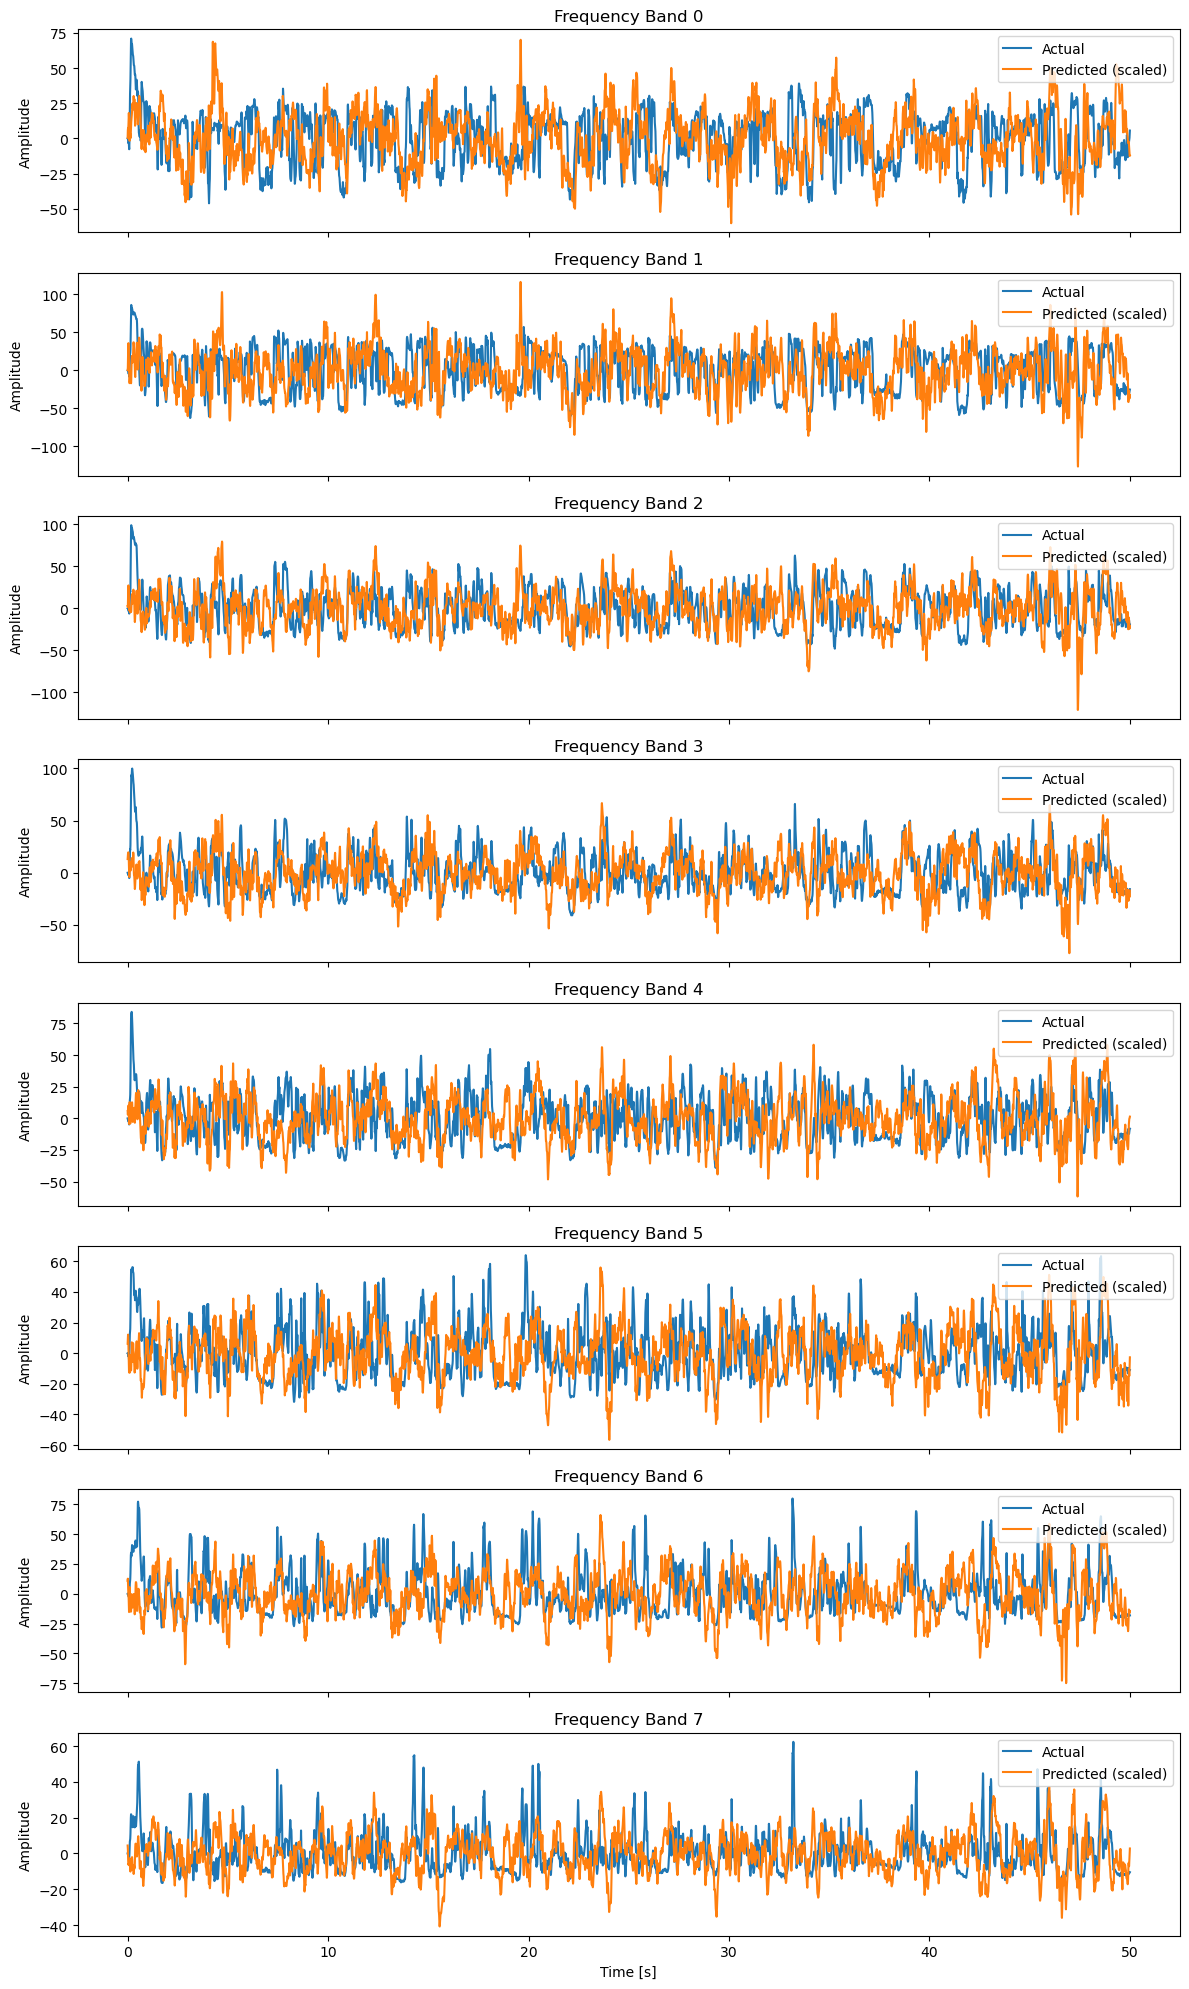

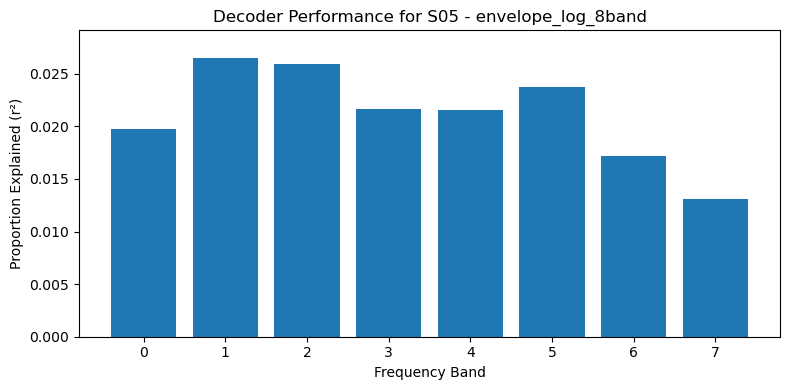

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Extract arrays
env = envelope.x
pred = predicted_envelope.x
time = envelope.time.times   # ← FIXED (extract numeric time values)

n_bands = env.shape[0]

# --------------------------------------------
# Restrict to first 50 seconds
# --------------------------------------------
t_max = 50
time_mask = time <= t_max

time_50 = time[time_mask]
env_50 = env[:, time_mask]
pred_50 = pred[:, time_mask]

# Scale predicted envelope for visualization ONLY
pred_scaled_50 = pred_50 * (env_50.std(axis=1) / pred_50.std(axis=1))[:, None]
#pred_scaled_50 = pred_50

# --------------------------------------------
# Plot each band in its own subplot
# --------------------------------------------
fig, axes = plt.subplots(n_bands, 1, figsize=(12, 2.5*n_bands), sharex=True)

for i in range(n_bands):
    ax = axes[i]
    ax.plot(time_50, env_50[i], label='Actual')
    ax.plot(time_50, pred_scaled_50[i], label='Predicted (scaled)')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Frequency Band {i}')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()


# --------------------------------------------
# Bar plot of r² (computed on full data)
# --------------------------------------------
plt.figure(figsize=(8, 4))
plt.bar(range(n_bands), r_squared_values)
plt.xlabel('Frequency Band')
plt.ylabel('Proportion Explained (r²)')
plt.title(f'Decoder Performance for {subject} - {model}')
plt.xticks(range(n_bands))
plt.ylim(0, max(r_squared_values)*1.1)
plt.tight_layout()
plt.show()

